# Mini-Challenge 2.3: Segmentation & Morphological Operations

## Day 11: Data & Domain

### Use Case: Alpine Ibex Population Census via Automated Object Extraction

Alpine ibex conservation depends on accurate population counts and individual tracking. Conservation rangers and biologists in the Swiss National Park analyze field photographs and camera trap imagery to:
1. **Detect and locate individual ibex** within complex natural scenes (sky, rock, vegetation)
2. **Measure individual properties** (size, shape) to support species verification and age estimation
3. **Automate census workflows** to process hundreds of images rapidly vs manual frame-by-frame review

Reliable object segmentation is essential: distinguishing foreground (ibex) from background (rocks, sky) despite variable lighting, occlusion, and complex texture.

### Problem Statement

**Challenge**: Single images may contain multiple ibex (2 in our reference image) with vastly different backgrounds (sky vs rock). Simple thresholding often fails because:
- Alpine ibex fur exhibits variable intensity (shadows, highlights, texture)
- Backgrounds (rock, sky) may have overlapping intensity ranges with fur
- Over-sensitive segmentation fragments objects; under-sensitive segmentation merges them

**Approach**: Combine intensity-based thresholding with morphological operations (erosion, dilation) to refine raw segmentation while preserving object shapes and extracting meaningful properties (area, perimeter, skeleton centerlines).

### Objective

Investigate how threshold selection and morphological operations affect object extraction accuracy and property stability. The goal: determine optimal parameter ranges for reliable automated counting and measurement in alpine ibex surveys.

## Day 12: Methodological Design

### Segmentation Strategy

**Thresholding Method**: Global thresholding using Otsu's automatic threshold selection, plus manual threshold adjustments for comparison.
- **Otsu's method**: Automatically selects threshold that maximizes between-class variance (reproducible, no manual tuning)
- **Manual adjustment**: Allows exploration of suboptimal thresholds to study robustness

**Morphological Operations**: Sequences of erosion and dilation to refine binary masks
- **Opening** (erosion → dilation): Removes small noise (salt-and-pepper artifacts) while preserving larger objects
- **Closing** (dilation → erosion): Fills small internal holes, connects fragmented regions
- **Kernel size**: Larger kernels → more aggressive processing; smaller kernels → minimal change

### Object Property Measures

For each extracted object:
1. **Area** (pixel count): Object size; supports counting and filtering by size
2. **Perimeter** (boundary length): Shape complexity; elongated objects vs compact
3. **Skeleton** (morphological skeleton): Centerline representation; aids shape recognition and pose estimation

### Configuration Definitions

| Configuration | Threshold Method | Kernel Size | Morphology | Purpose |
|:---|:---|---:|:---|:---:|
| **C0 Baseline** | Otsu automatic | 3×3 | Opening only | Minimal processing, automatic threshold |
| **C1 Refined** | Otsu + manual adjust | 5×5 | Opening + closing | Cleaner objects, remove noise and fill holes |
| **C2 Aggressive** | Manual lower threshold | 7×7 | Opening + closing | Capture more detail, may include boundary noise |

**Parameter Justification**:
- Otsu is reproducible, automatic, and widely used in wildlife detection systems
- Kernel sizes scale from minimal (3×3) to aggressive (7×7) morphology
- Opening removes salt-and-pepper noise typical in alpine photography
- Closing fills internal voids in dark fur regions, improving connectivity
- Manual threshold in C2 set 20% below Otsu value to test sensitivity to under-segmentation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import cv2
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully")

Libraries imported successfully


## Day 13: Technical Implementation

### Step 1: Load and Prepare Image

Image dimensions: 3024×4032
ROI dimensions: (1512, 2419)
ROI area: 3657528 pixels


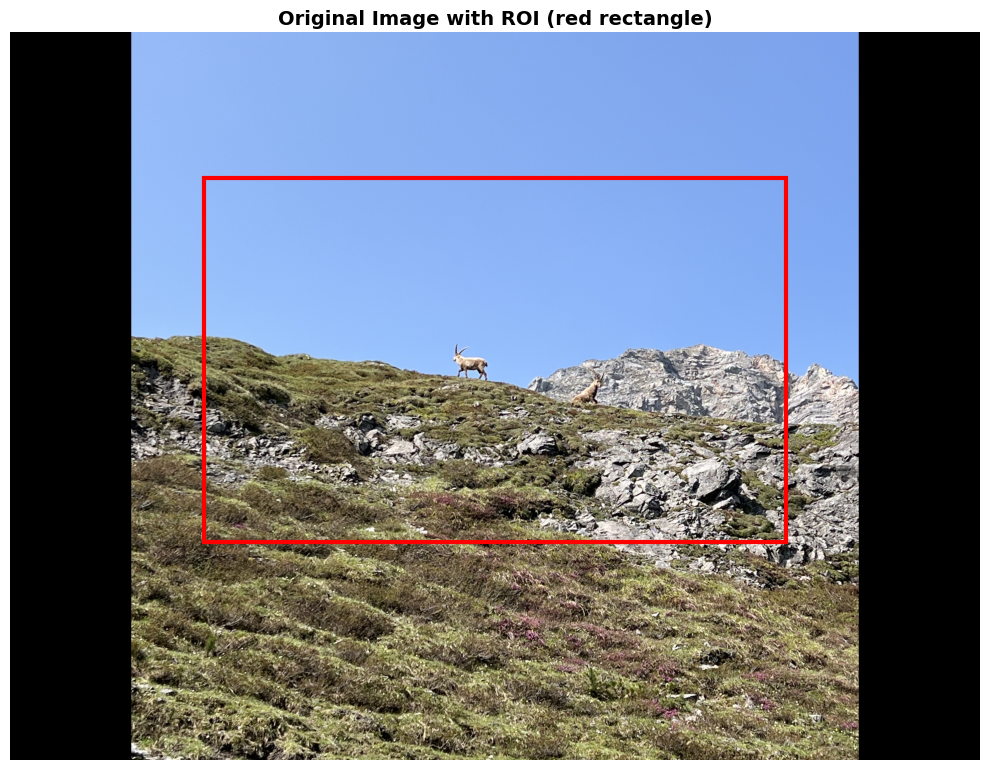


Image loaded and ROI defined


In [2]:
# Load reference image
img_path = './Data/Steinbock.jpg'
img = Image.open(img_path)

# Rotate 90° clockwise for proper orientation
img = img.rotate(-90, expand=False)

# Convert to numpy array and get dimensions
img = np.array(img)
h, w = img.shape[:2]

# Convert to grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Define ROI (Region of Interest) - consistent with MC2.2
y0, y1 = int(h * 0.2), int(h * 0.7)
x0, x1 = int(w * 0.2), int(w * 0.8)
roi_gray = img_gray[y0:y1, x0:x1]

print(f"Image dimensions: {h}×{w}")
print(f"ROI dimensions: {roi_gray.shape}")
print(f"ROI area: {(y1-y0)*(x1-x0)} pixels")

# Display original image with ROI overlay
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
ax.imshow(img)
rect = Rectangle((x0, y0), x1-x0, y1-y0, linewidth=3, edgecolor='red', facecolor='none')
ax.add_patch(rect)
ax.set_title('Original Image with ROI (red rectangle)', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print("\nImage loaded and ROI defined")

### Step 2: Apply Otsu Thresholding and Determine Threshold Values

In [3]:
# Compute Otsu threshold on ROI for consistency
otsu_threshold, _ = cv2.threshold(roi_gray, 0, 255, cv2.THRESH_OTSU)

print(f"Otsu automatic threshold: {otsu_threshold}")

# Define configuration thresholds
configs = {
    "C0 Baseline": {
        "threshold": otsu_threshold,
        "kernel_size": 3,
        "close": False,
        "description": "Otsu automatic, minimal morphology"
    },
    "C1 Refined": {
        "threshold": otsu_threshold,
        "kernel_size": 5,
        "close": True,
        "description": "Otsu automatic, refined morphology"
    },
    "C2 Aggressive": {
        "threshold": int(otsu_threshold * 0.8),  # 20% lower than Otsu
        "kernel_size": 7,
        "close": True,
        "description": "Lower threshold, aggressive morphology"
    },
}

print("\nConfiguration parameters:")
for config_name, params in configs.items():
    print(f"{config_name}: T={params['threshold']}, kernel={params['kernel_size']}, close={params['close']}")

Otsu automatic threshold: 128.0

Configuration parameters:
C0 Baseline: T=128.0, kernel=3, close=False
C1 Refined: T=128.0, kernel=5, close=True
C2 Aggressive: T=102, kernel=7, close=True


### Step 3: Apply Thresholding and Morphological Operations

In [7]:
# Store results for each configuration
segmentation_results = {}
object_properties = {}
MIN_OBJECT_AREA = 100  # Filter out objects smaller than this (noise suppression)

for config_name, params in configs.items():
    # Apply thresholding (invert: foreground=255, background=0)
    _, binary = cv2.threshold(roi_gray, params['threshold'], 255, cv2.THRESH_BINARY_INV)
    
    # Create morphological kernel
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (params['kernel_size'], params['kernel_size']))
    
    # Apply opening (erosion -> dilation)
    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    
    # Apply closing if specified
    if params['close']:
        result = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=1)
    else:
        result = opened
    
    segmentation_results[config_name] = result
    
    # Extract connected components
    num_labels, labels = cv2.connectedComponents(result, connectivity=8)
    
    # Compute properties for each object (skip background label 0)
    areas = []
    perimeters = []
    skeletons = []
    
    for label_idx in range(1, num_labels):
        mask = (labels == label_idx).astype(np.uint8) * 255
        
        # Area
        area = np.sum(labels == label_idx)
        
        # Filter out noise (objects smaller than MIN_OBJECT_AREA)
        if area < MIN_OBJECT_AREA:
            continue
        
        areas.append(area)
        
        # Perimeter
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            perimeter = cv2.arcLength(contours[0], True)
            perimeters.append(perimeter)
        
        # Skeleton via morphological thinning (erode until cannot erode further)
        skeleton = mask.copy().astype(np.uint8)
        prev = np.zeros_like(skeleton)
        kernel_thin = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        iter_count = 0
        while not np.array_equal(skeleton, prev) and iter_count < 50:  # Max 50 iterations
            prev = skeleton.copy()
            eroded = cv2.erode(skeleton, kernel_thin, iterations=1)
            temp = cv2.dilate(eroded, kernel_thin, iterations=1)
            skeleton = cv2.subtract(skeleton, temp)
            iter_count += 1
        skeletons.append(skeleton)
    
    object_properties[config_name] = {
        'num_objects': len(areas),  # After filtering
        'areas': areas,
        'perimeters': perimeters,
        'skeletons': skeletons,
        'labeled': labels,
        'raw_num_objects': num_labels - 1  # Before filtering
    }
    
    print(f"\n{config_name}:")
    print(f"  Objects detected (raw): {num_labels - 1}, (filtered >={MIN_OBJECT_AREA}px): {len(areas)}")
    if areas:
        print(f"  Mean area: {np.mean(areas):.1f} ± {np.std(areas):.1f} pixels")
        print(f"  Mean perimeter: {np.mean(perimeters):.1f} ± {np.std(perimeters):.1f} pixels")
    print(f"  Total pixels in ROI: {np.sum(result > 0)}")


C0 Baseline:
  Objects detected (raw): 1546, (filtered >=100px): 295
  Mean area: 3290.3 ± 42406.8 pixels
  Mean perimeter: 359.1 ± 2870.7 pixels
  Total pixels in ROI: 1005326

C1 Refined:
  Objects detected (raw): 650, (filtered >=100px): 212
  Mean area: 4589.3 ± 50182.0 pixels
  Mean perimeter: 340.0 ± 2113.5 pixels
  Total pixels in ROI: 989695

C2 Aggressive:
  Objects detected (raw): 720, (filtered >=100px): 370
  Mean area: 1460.1 ± 7675.6 pixels
  Mean perimeter: 199.2 ± 516.1 pixels
  Total pixels in ROI: 558897


### Step 4: Visualize Segmentation Results

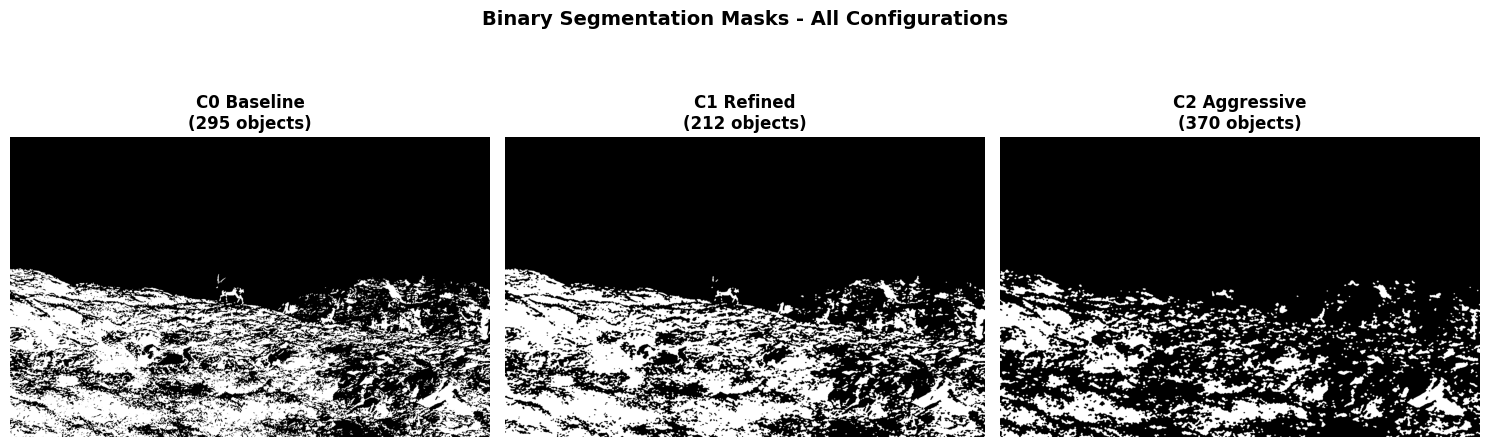

Segmentation masks displayed


In [8]:
# Create 3-panel comparison of binary masks
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (config_name, binary_mask) in enumerate(segmentation_results.items()):
    ax = axes[idx]
    ax.imshow(binary_mask, cmap='gray')
    ax.set_title(f'{config_name}\n({object_properties[config_name]["num_objects"]} objects)', 
                 fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Binary Segmentation Masks - All Configurations', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Segmentation masks displayed")

### Step 5: Visualize Labeled Connected Components with Color Map

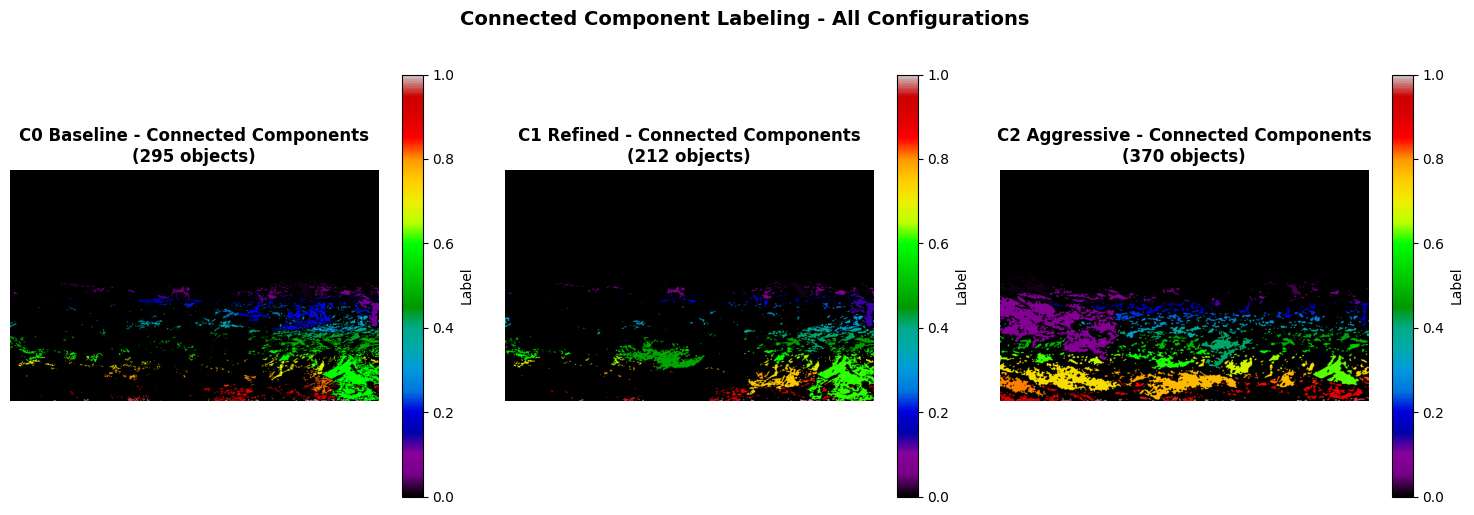

Connected components displayed


In [9]:
# Create 3-panel labeled component visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, config_name in enumerate(segmentation_results.keys()):
    ax = axes[idx]
    labeled_img = object_properties[config_name]['labeled'].astype(float)
    
    # Normalize for better visualization (background=0 -> black)
    if labeled_img.max() > 0:
        labeled_normalized = labeled_img / labeled_img.max()
    else:
        labeled_normalized = labeled_img
    
    im = ax.imshow(labeled_normalized, cmap='nipy_spectral')
    ax.set_title(f'{config_name} - Connected Components\n({object_properties[config_name]["num_objects"]} objects)',
                fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, label='Label')

plt.suptitle('Connected Component Labeling - All Configurations', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Connected components displayed")

### Step 6: Visualize Skeleton Centerlines

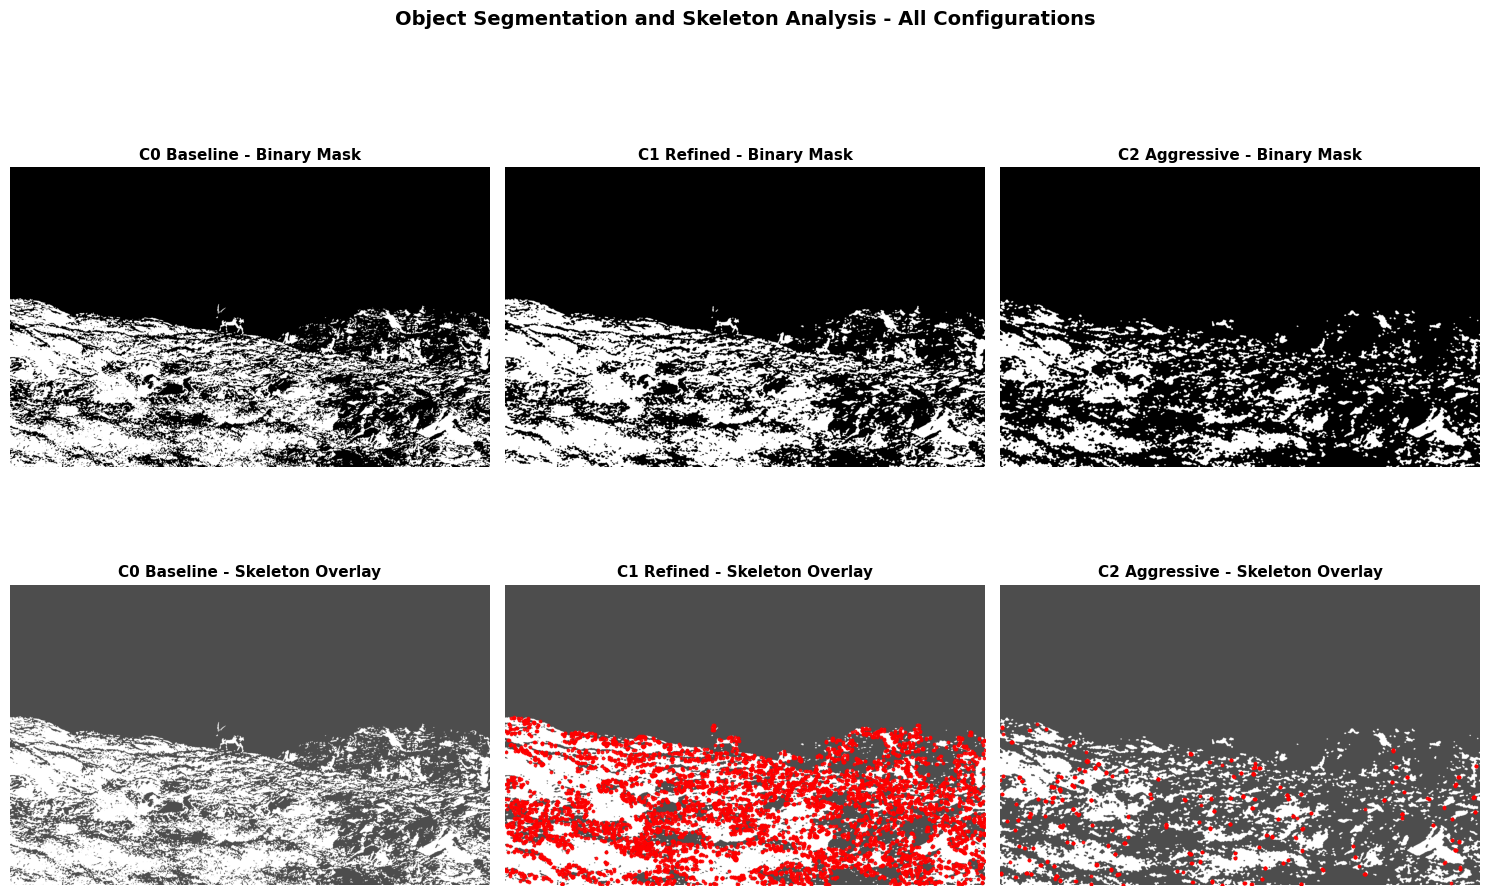

Skeleton visualizations displayed


In [10]:
# Create visualization of skeleton centerlines for first detected object in each config
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Object Segmentation and Skeleton Analysis - All Configurations', 
             fontsize=14, fontweight='bold', y=1.00)

for col_idx, config_name in enumerate(segmentation_results.keys()):
    # Top row: segmentation mask
    ax_top = axes[0, col_idx]
    ax_top.imshow(segmentation_results[config_name], cmap='gray')
    ax_top.set_title(f'{config_name} - Binary Mask', fontsize=11, fontweight='bold')
    ax_top.axis('off')
    
    # Bottom row: segmentation mask + skeleton overlay
    ax_bottom = axes[1, col_idx]
    
    # Show binary mask as background
    ax_bottom.imshow(segmentation_results[config_name], cmap='gray', alpha=0.7)
    
    # Overlay skeletons in red if available
    if object_properties[config_name]['skeletons']:
        combined_skeleton = np.zeros_like(segmentation_results[config_name])
        for skeleton in object_properties[config_name]['skeletons']:
            combined_skeleton = np.maximum(combined_skeleton, skeleton)
        
        # Show skeleton in red
        skeleton_coords = np.where(combined_skeleton > 0)
        ax_bottom.scatter(skeleton_coords[1], skeleton_coords[0], c='red', s=3, alpha=0.8)
    
    ax_bottom.set_title(f'{config_name} - Skeleton Overlay', fontsize=11, fontweight='bold')
    ax_bottom.axis('off')

plt.tight_layout()
plt.show()

print("Skeleton visualizations displayed")